# Driver Drowsiness Detection using Eye Closure and Yawning Analysis with Deep Learning

## Project Overview

Driver fatigue is a major road safety concern that can reduce alertness, reaction time, and decision-making ability.

This project develops a vision-based driver drowsiness detection system using facial indicators such as eye closure and yawning.

The system classifies facial images into four categories:

- Eyes Open
- Eyes Closed
- Yawn
- No Yawn

Two deep learning approaches are implemented and compared:

1. Custom Convolutional Neural Network (CNN)
2. Transfer Learning using MobileNetV2

The trained models are evaluated using accuracy, precision, recall, confusion matrix, and unseen test data.

Finally, eye and mouth state predictions are combined using rule-based decision logic to classify driver fatigue into three levels:

- Alert
- Mild Fatigue
- Severe Fatigue

A fatigue progression curve is also generated to visualize how fatigue changes over a simulated driving session.

## Problem Statement

Driver fatigue and drowsiness can reduce alertness, reaction time, and decision-making ability, increasing the risk of road accidents.

Traditional approaches for detecting driver fatigue may rely on vehicle behavior or wearable devices. These approaches can be intrusive or may not reliably capture visible signs of fatigue.

This project aims to develop a non-intrusive, vision-based driver drowsiness detection system using facial indicators such as eye closure and yawning. Deep learning techniques are used to classify facial images into four states: Closed, Open, No Yawn, and Yawn.

The predicted states are then converted into three fatigue levels: Alert, Mild Fatigue, and Severe Fatigue.

## Project Objectives

- Detect eye states such as Open and Closed.
- Detect mouth states such as No Yawn and Yawn.
- Preprocess and augment facial images for deep learning.
- Develop a Custom CNN model for four-class classification.
- Develop a MobileNetV2 transfer learning model.
- Compare the performance of both models using test accuracy, precision, recall, and confusion matrices.
- Convert four-class predictions into three fatigue levels using rule-based decision logic.
- Demonstrate fatigue progression using sequential predictions.
- Analyze model performance, limitations, and potential real-world applications.

In [2]:
import os
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("Random seed:", SEED)

All libraries imported successfully!
TensorFlow version: 2.20.0
Keras version: 3.13.2
Random seed: 42


In [3]:
# Check GPU availability

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU is available!")
    print("GPU:", gpus[0])
else:
    print("GPU is not available. Training will use CPU.")

GPU is available!
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [4]:
# Mount Google Drive

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# Check Google Drive contents

drive_path = "/content/drive/MyDrive"

print("Google Drive connected successfully!")
print("\nFiles and folders in MyDrive:")
print(os.listdir(drive_path))

Google Drive connected successfully!

Files and folders in MyDrive:
['train', 'Karthick.pdf', 'SIGN BALAJI.jpg', 'BALAJI.jpg', 'Colab Notebooks', 'Sample_data', 'bala73507.pdf', 'Copy of MDT58_HandsOnProjects.ipynb', 'Copy of MDT58_6DL.ipynb', 'Copy of MDT58_2.ipynb', 'Copy of MDT58_1.ipynb', 'Copy of MDT58_AWS.ipynb', 'Copy of MDT58_5ML.ipynb', 'Copy of MDT58_7DL.ipynb', 'Copy of MDT58_3.ipynb', 'Copy of MDT58_4.ipynb', 'Driver_Drowsiness_Detection.zip', 'Driver_Drowsiness_Detection']


In [6]:
# Inspect the Driver Drowsiness Detection project folder

project_path = "/content/drive/MyDrive/Driver_Drowsiness_Detection"

print("Project folder exists:", os.path.exists(project_path))

if os.path.exists(project_path):
    print("\nContents of Driver_Drowsiness_Detection:")
    print(os.listdir(project_path))

Project folder exists: True

Contents of Driver_Drowsiness_Detection:
['data', 'models', 'src', 'app.py', 'requirements.txt', 'README.md', 'main.py', 'colab_dataset']


In [7]:
# Inspect the data folder

data_path = os.path.join(project_path, "data")

print("Data folder exists:", os.path.exists(data_path))

if os.path.exists(data_path):
    print("\nContents of data folder:")
    print(os.listdir(data_path))

Data folder exists: True

Contents of data folder:
['test', 'train', 'train_split', 'validation']


## Dataset Description

The dataset used in this project contains facial images representing four classes related to driver drowsiness detection:

- **Closed** — Eyes are closed.
- **Open** — Eyes are open.
- **no_yawn** — No yawning is present.
- **yawn** — Yawning is present.

The original dataset contains **2,900 images** distributed across the four classes.

The class distribution is approximately balanced:

| Class | Image Count |
|---|---:|
| Closed | 726 |
| Open | 726 |
| no_yawn | 725 |
| yawn | 723 |
| **Total** | **2,900** |

The dataset was divided into three subsets for model development and evaluation:

- **Training set:** 2,029 images
- **Validation set:** 435 images
- **Test set:** 436 images

The original dataset was kept unchanged, and a fresh train-validation-test split was created for this implementation.

In [7]:
# Inspect the original training dataset

original_train_path = os.path.join(data_path, "train")

print("Original train folder exists:", os.path.exists(original_train_path))

if os.path.exists(original_train_path):
    class_names = sorted(os.listdir(original_train_path))

    print("\nClasses in the original dataset:")
    for class_name in class_names:
        print("-", class_name)

Original train folder exists: True

Classes in the original dataset:
- Closed
- Open
- no_yawn
- yawn


In [8]:
# Count images in each class

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(original_train_path, class_name)

    count = sum(
        1 for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    )

    class_counts[class_name] = count

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image Count"]
)

print(class_counts_df)

     Class  Image Count
0   Closed          726
1     Open          726
2  no_yawn          725
3     yawn          723


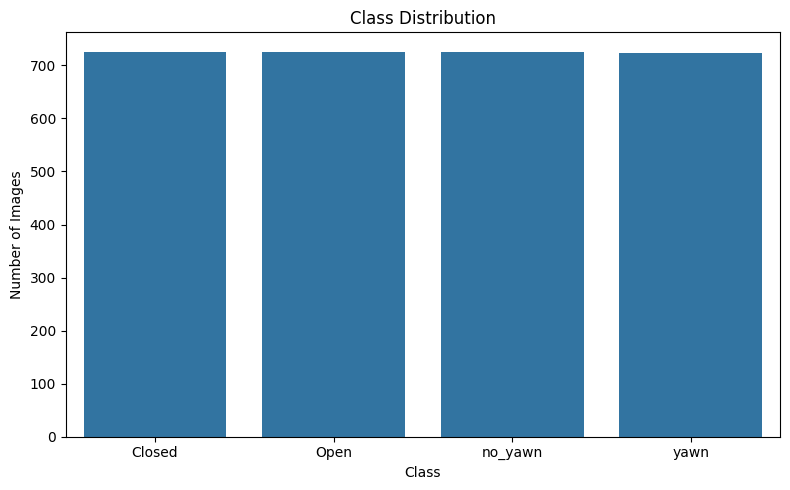

In [9]:
# Visualize class distribution

plt.figure(figsize=(8, 5))

sns.barplot(
    data=class_counts_df,
    x="Class",
    y="Image Count"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## EDA and Data Quality Findings

Exploratory Data Analysis (EDA) was performed to understand the dataset structure, class distribution, image dimensions, image quality, and data integrity.

### Class Distribution

The dataset is approximately balanced across the four classes:

- Closed: 726 images
- Open: 726 images
- no_yawn: 725 images
- yawn: 723 images

The small difference in class counts is not significant, so no additional class-balancing technique was required.

### Image Dimensions

The dataset contains images with varying widths and heights. The analysis identified differences in image resolution across the dataset.

To provide a consistent input format for deep learning models, all images are resized to **224 × 224 pixels** during preprocessing.

### Image Quality

A low-resolution analysis identified **140 images (4.83%)** where either the width or height was below 100 pixels.

These images were retained to preserve dataset variation and were resized to 224 × 224 pixels during preprocessing.

All **2,900 images were readable**, and no corrupted or unreadable images were detected.

### Duplicate Analysis

A duplicate audit was performed to identify repeated image contents across the available dataset folders.

The original training dataset contains **2,900 unique image contents**. Previous split folders contained duplicate copies of these images, so a fresh train-validation-test split was created from the original dataset for the final implementation.

This approach helps maintain a clean and reproducible dataset split and avoids accidental data leakage.

In [10]:
# Check for duplicate images across dataset splits

import hashlib

split_names = ["train", "train_split", "validation", "test"]

split_paths = {
    split: os.path.join(data_path, split)
    for split in split_names
}

def get_image_hash(file_path):
    """Return a SHA-256 hash for an image file."""

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for chunk in iter(lambda: file.read(8192), b""):
            sha256.update(chunk)

    return sha256.hexdigest()


hash_records = []

for split_name, split_path in split_paths.items():

    if not os.path.exists(split_path):
        continue

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):

            if not file_name.lower().endswith(image_extensions):
                continue

            file_path = os.path.join(class_path, file_name)

            hash_records.append({
                "split": split_name,
                "class": class_name,
                "file_name": file_name,
                "hash": get_image_hash(file_path)
            })

hash_df = pd.DataFrame(hash_records)

print("Total image files audited:", len(hash_df))
print("Unique image contents:", hash_df["hash"].nunique())
print("Duplicate file occurrences:", len(hash_df) - hash_df["hash"].nunique())

Total image files audited: 5800
Unique image contents: 2900
Duplicate file occurrences: 2900


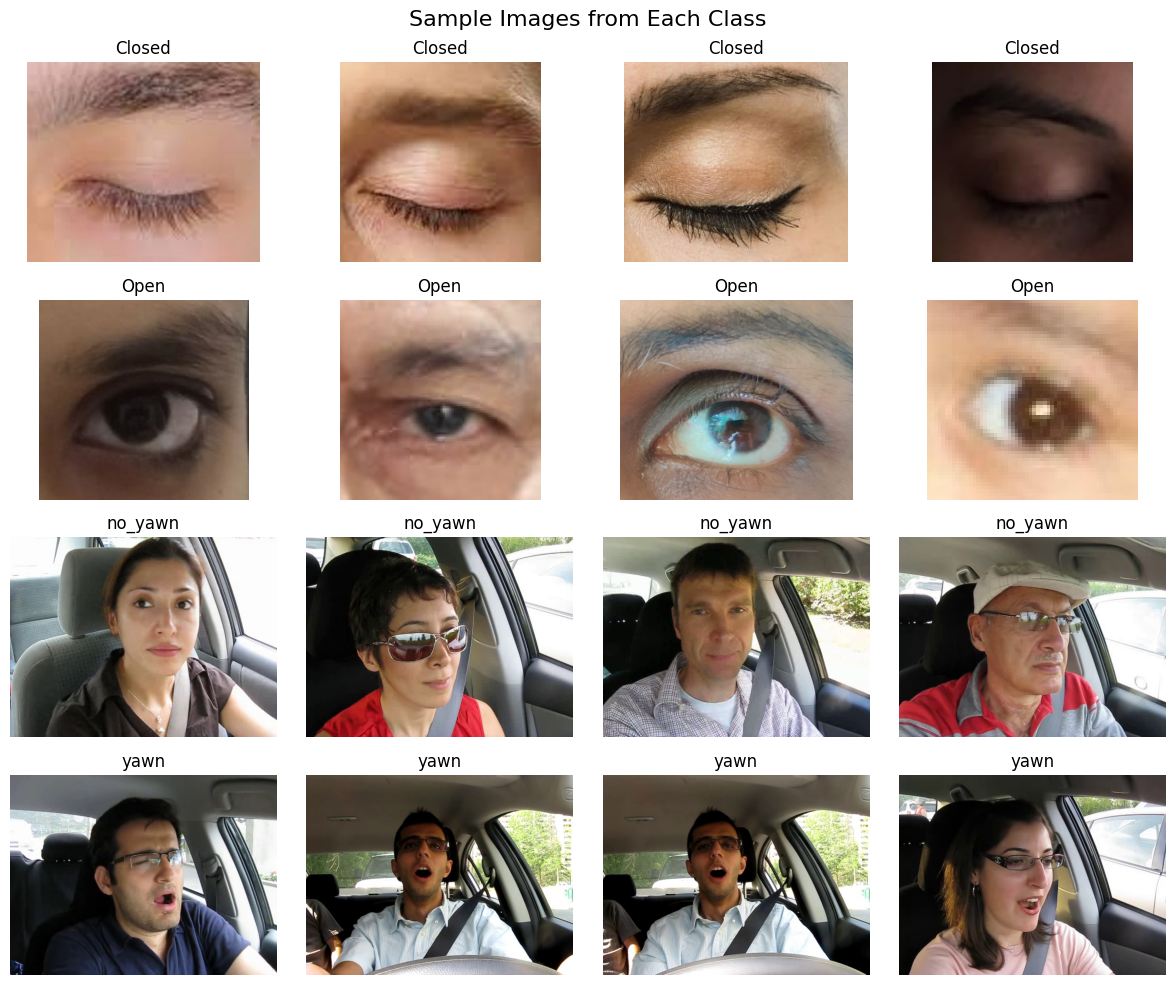

In [11]:
# Display sample images from each class

import random
from PIL import Image

samples_per_class = 4

fig, axes = plt.subplots(
    len(class_names),
    samples_per_class,
    figsize=(12, 10)
)

for row, class_name in enumerate(class_names):

    class_path = os.path.join(original_train_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    ]

    selected_images = random.sample(
        image_files,
        samples_per_class
    )

    for col, file_name in enumerate(selected_images):

        image_path = os.path.join(class_path, file_name)
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.suptitle(
    "Sample Images from Each Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [12]:
# Analyze image dimensions across the dataset

from PIL import Image

dimension_records = []

for class_name in class_names:
    class_path = os.path.join(original_train_path, class_name)

    for file_name in os.listdir(class_path):

        if not file_name.lower().endswith(image_extensions):
            continue

        file_path = os.path.join(class_path, file_name)

        with Image.open(file_path) as image:
            width, height = image.size

        dimension_records.append({
            "Class": class_name,
            "Width": width,
            "Height": height
        })

dimensions_df = pd.DataFrame(dimension_records)

print("Total images analyzed:", len(dimensions_df))
print("\nImage dimension summary:")
print(dimensions_df[["Width", "Height"]].describe())

Total images analyzed: 2900

Image dimension summary:
             Width       Height
count  2900.000000  2900.000000
mean    490.285517   396.782069
std     219.070298   177.410530
min      50.000000    40.000000
25%     304.000000   300.000000
50%     640.000000   480.000000
75%     640.000000   480.000000
max    1625.000000  1625.000000


In [13]:
# Check for corrupted or unreadable images

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(original_train_path, class_name)

    for file_name in os.listdir(class_path):

        if not file_name.lower().endswith(image_extensions):
            continue

        file_path = os.path.join(class_path, file_name)

        try:
            with Image.open(file_path) as image:
                image.verify()

        except Exception:
            corrupted_images.append(file_path)

print("Total images checked:", len(dimensions_df))
print("Corrupted/unreadable images:", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted image files:")
    for file_path in corrupted_images:
        print(file_path)
else:
    print("All images are readable.")

Total images checked: 2900
Corrupted/unreadable images: 0
All images are readable.


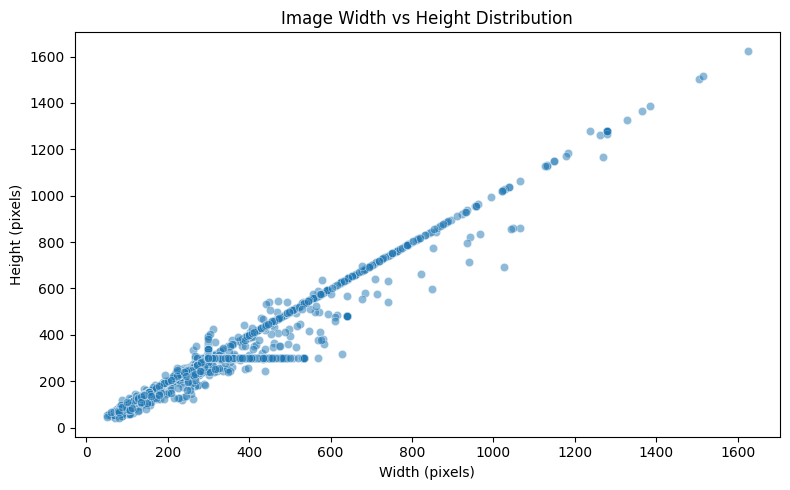

In [14]:
# Visualize image dimension distribution

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=dimensions_df,
    x="Width",
    y="Height",
    alpha=0.5
)

plt.title("Image Width vs Height Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.tight_layout()
plt.show()

In [16]:
# Analyze potentially low-resolution images

low_quality_images = dimensions_df[
    (dimensions_df["Width"] < 100) |
    (dimensions_df["Height"] < 100)
]

print("Potentially low-resolution images:", len(low_quality_images))
print(
    "Percentage of potentially low-resolution images:",
    round(len(low_quality_images) / len(dimensions_df) * 100, 2),
    "%"
)

Potentially low-resolution images: 140
Percentage of potentially low-resolution images: 4.83 %


In [17]:
# Define image preprocessing settings

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [22]:
# Create fresh train, validation, and test splits

from sklearn.model_selection import train_test_split
import shutil

split_base_path = os.path.join(project_path, "colab_dataset")

train_split_path = os.path.join(split_base_path, "train")
validation_split_path = os.path.join(split_base_path, "validation")
test_split_path = os.path.join(split_base_path, "test")

# Create split folders
for split_path in [
    train_split_path,
    validation_split_path,
    test_split_path
]:
    for class_name in class_names:
        os.makedirs(
            os.path.join(split_path, class_name),
            exist_ok=True
        )

print("Fresh dataset split folders created!")

Fresh dataset split folders created!


In [23]:
# Split images into train, validation, and test sets

for class_name in class_names:

    class_path = os.path.join(original_train_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    ]

    # First split: 70% train, 30% temporary
    train_files, temp_files = train_test_split(
        image_files,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    # Second split: temporary into 15% validation and 15% test
    validation_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    # Copy training images
    for file_name in train_files:
        shutil.copy2(
            os.path.join(class_path, file_name),
            os.path.join(train_split_path, class_name, file_name)
        )

    # Copy validation images
    for file_name in validation_files:
        shutil.copy2(
            os.path.join(class_path, file_name),
            os.path.join(validation_split_path, class_name, file_name)
        )

    # Copy test images
    for file_name in test_files:
        shutil.copy2(
            os.path.join(class_path, file_name),
            os.path.join(test_split_path, class_name, file_name)
        )

print("Dataset split completed successfully!")

Dataset split completed successfully!


In [24]:
# Verify image counts in train, validation, and test sets

split_paths = {
    "Train": train_split_path,
    "Validation": validation_split_path,
    "Test": test_split_path
}

split_count_records = []

for split_name, split_path in split_paths.items():

    for class_name in class_names:

        class_path = os.path.join(split_path, class_name)

        image_count = sum(
            1 for file_name in os.listdir(class_path)
            if file_name.lower().endswith(image_extensions)
        )

        split_count_records.append({
            "Split": split_name,
            "Class": class_name,
            "Image Count": image_count
        })

split_counts_df = pd.DataFrame(split_count_records)

print(split_counts_df)

print("\nTotal images in each split:")
print(split_counts_df.groupby("Split")["Image Count"].sum())

print(
    "\nGrand Total:",
    split_counts_df["Image Count"].sum()
)

         Split    Class  Image Count
0        Train   Closed          508
1        Train     Open          508
2        Train  no_yawn          507
3        Train     yawn          506
4   Validation   Closed          109
5   Validation     Open          109
6   Validation  no_yawn          109
7   Validation     yawn          108
8         Test   Closed          109
9         Test     Open          109
10        Test  no_yawn          109
11        Test     yawn          109

Total images in each split:
Split
Test           436
Train         2029
Validation     435
Name: Image Count, dtype: int64

Grand Total: 2900


In [25]:
# Create image preprocessing and augmentation pipelines

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

print("Preprocessing pipelines created successfully!")

Preprocessing pipelines created successfully!


## Preprocessing and Data Augmentation

Image preprocessing was performed to prepare the dataset for deep learning models.

### Preprocessing Steps

- All input images were resized to **224 × 224 pixels**.
- Pixel values were normalized to the range **0–1** using rescaling by `1/255`.
- The same image size and normalization were applied to the training, validation, and test datasets.

### Data Augmentation

Data augmentation was applied only to the training dataset to improve model generalization and reduce overfitting.

The following augmentation techniques were used:

- **Rotation:** Random rotation up to 15 degrees.
- **Zoom:** Random zoom up to 15%.
- **Brightness variation:** Brightness adjusted within the range of 0.8 to 1.2.
- **Horizontal flipping:** Random horizontal flipping.

Validation and test images were only normalized and were not augmented, ensuring that model evaluation was performed on unchanged images.

In [26]:
# Load train, validation, and test images

train_generator = train_datagen.flow_from_directory(
    train_split_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen.flow_from_directory(
    validation_split_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_split_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nDataset generators created successfully!")

Found 2029 images belonging to 4 classes.
Found 435 images belonging to 4 classes.
Found 436 images belonging to 4 classes.

Dataset generators created successfully!


In [27]:
# Check class-to-index mapping

print("Class mapping:")
print(train_generator.class_indices)

Class mapping:
{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


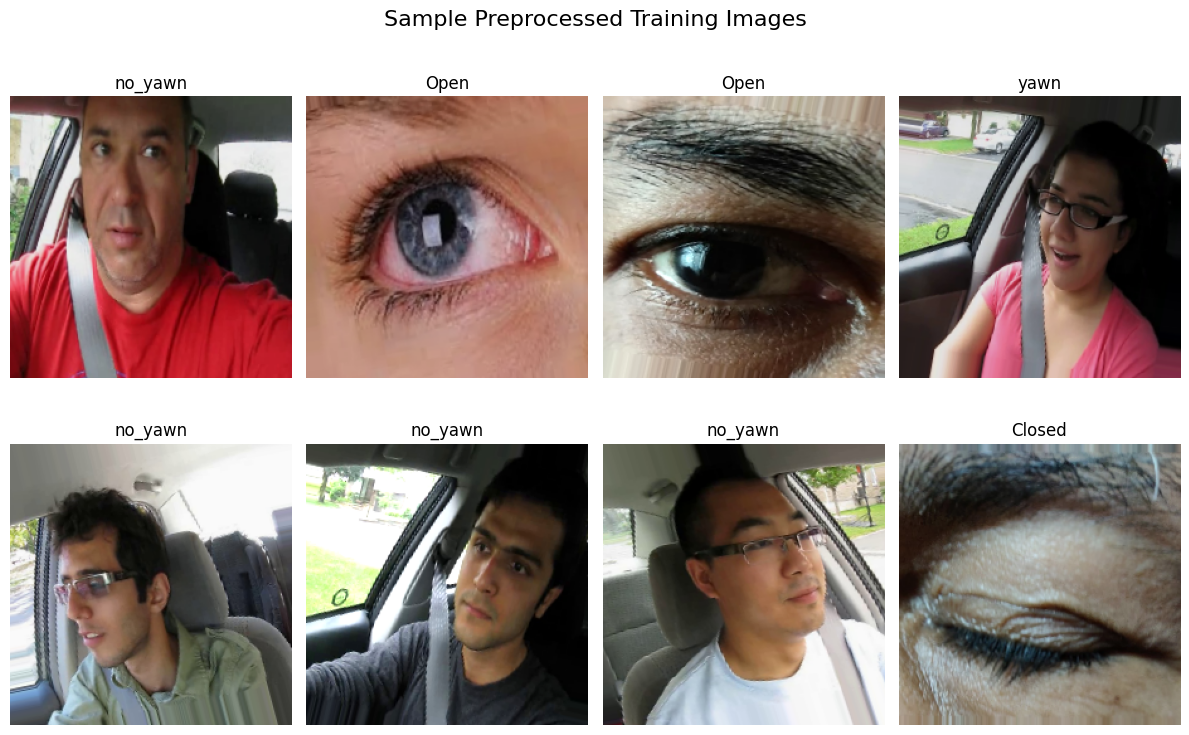

In [28]:
# Display a batch of preprocessed training images

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.suptitle("Sample Preprocessed Training Images", fontsize=16)
plt.tight_layout()
plt.show()

In [29]:
# Build a custom Convolutional Neural Network

custom_cnn = keras.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(4, activation="softmax")
])

print("Custom CNN created successfully!")

Custom CNN created successfully!


## Custom CNN Architecture

A Custom Convolutional Neural Network (CNN) was developed as a baseline deep learning model for four-class image classification.

The architecture consists of:

- **Four convolutional layers** with 32, 64, 128, and 256 filters.
- **MaxPooling layers** after each convolutional layer to reduce spatial dimensions.
- A **Flatten layer** to convert extracted feature maps into a one-dimensional representation.
- A **Dense layer with 128 neurons** for classification feature learning.
- **Dropout with a rate of 0.5** to reduce overfitting.
- A final **Softmax output layer with 4 neurons** corresponding to Closed, Open, no_yawn, and yawn classes.

The model learns visual features directly from the training images and provides a baseline for comparison with the MobileNetV2 transfer learning model.

In [30]:
# Display the Custom CNN architecture

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,652 (19.48 MB)

 Trainable params: 5,107,652 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile the Custom CNN

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Custom CNN compiled successfully!")

Custom CNN compiled successfully!


In [32]:
# Check GPU before starting model training

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU is available for training!")
    print("GPU:", gpus[0])
else:
    print("GPU is not available.")
    print("Training will use CPU.")

GPU is available for training!
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [33]:
# Train the Custom CNN

EPOCHS = 15

start_time = time.time()

custom_cnn_history = custom_cnn.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

training_time = time.time() - start_time

print("\nCustom CNN training completed!")
print(f"Training time: {training_time / 60:.2f} minutes")

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 728ms/step - accuracy: 0.5771 - loss: 0.9265 - val_accuracy: 0.7241 - val_loss: 0.5024
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 646ms/step - accuracy: 0.7620 - loss: 0.4896 - val_accuracy: 0.8000 - val_loss: 0.3725
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 625ms/step - accuracy: 0.7575 - loss: 0.4346 - val_accuracy: 0.8138 - val_loss: 0.3955
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 629ms/step - accuracy: 0.7777 - loss: 0.4006 - val_accuracy: 0.8046 - val_loss: 0.3566
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 639ms/step - accuracy: 0.7679 - loss: 0.3978 - val_accuracy: 0.8092 - val_loss: 0.3676
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 639ms/step - accuracy: 0.7965 - loss: 0.3718 - val_accuracy: 0.8345 - val_loss: 0.3183
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 664ms/step - accuracy: 0.7969 - loss: 0.3589 - val_accuracy: 0.8230 - val_loss: 0.3439
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 640ms/step - accuracy: 0.8088 - loss: 0.3491 - val_accu

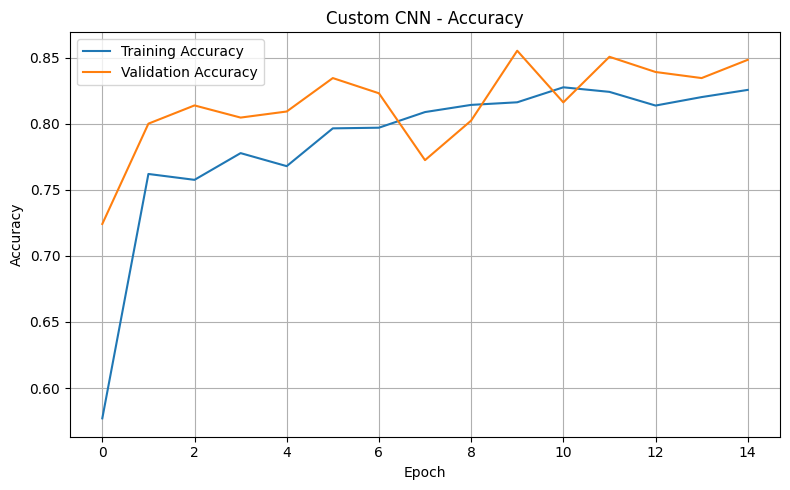

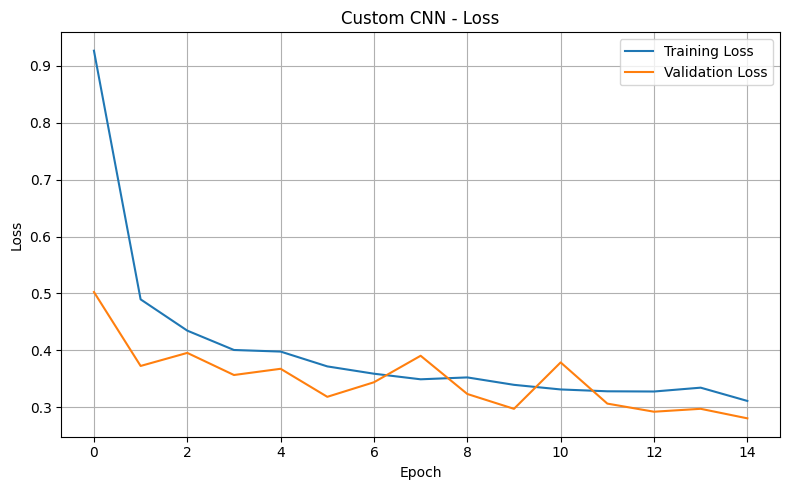

In [34]:
# Plot Custom CNN training and validation performance

history_df = pd.DataFrame(custom_cnn_history.history)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Custom CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.title("Custom CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# Save the trained Custom CNN model

custom_cnn_save_path = os.path.join(
    project_path,
    "models",
    "colab_custom_cnn.keras"
)

custom_cnn.save(custom_cnn_save_path)

print("Custom CNN saved successfully!")
print("Saved path:", custom_cnn_save_path)

Custom CNN saved successfully!
Saved path: /content/drive/MyDrive/Driver_Drowsiness_Detection/models/colab_custom_cnn.keras


In [36]:
# Evaluate Custom CNN on the unseen test dataset

test_loss, test_accuracy = custom_cnn.evaluate(test_generator, verbose=1)

print("\nCustom CNN Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 0.8119 - loss: 0.3273

Custom CNN Test Results
Test Loss: 0.3273
Test Accuracy: 0.8119
Test Accuracy: 81.19%


In [37]:
# Generate predictions on the unseen test dataset

test_generator.reset()

predictions = custom_cnn.predict(test_generator, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))
print("Number of true labels:", len(y_true))

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step
Predictions generated successfully!
Number of predictions: 436
Number of true labels: 436


In [38]:
# Calculate precision, recall, and classification report

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Custom CNN Evaluation Metrics")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

Custom CNN Evaluation Metrics
Precision: 0.8132
Recall: 0.8119

Classification Report:
              precision    recall  f1-score   support

      Closed       0.99      0.94      0.97       109
        Open       0.96      0.99      0.97       109
     no_yawn       0.65      0.69      0.67       109
        yawn       0.66      0.62      0.64       109

    accuracy                           0.81       436
   macro avg       0.81      0.81      0.81       436
weighted avg       0.81      0.81      0.81       436



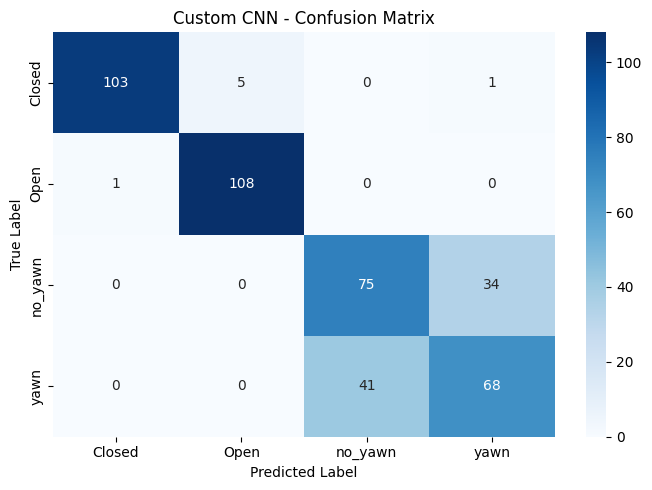

In [39]:
# Create confusion matrix for Custom CNN

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Custom CNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Evaluation Methodology

The trained models were evaluated using the unseen test dataset to measure their classification performance.

The following evaluation metrics were used:

- **Accuracy:** Measures the overall proportion of correctly classified images.
- **Precision:** Measures how accurately the model identifies each predicted class.
- **Recall:** Measures how effectively the model identifies the actual samples belonging to each class.
- **Confusion Matrix:** Shows the number of correct and incorrect predictions for each class.
- **Classification Report:** Provides precision, recall, and F1-score for each individual class.

Both the Custom CNN and MobileNetV2 models were evaluated using the same test dataset for a fair comparison.

The evaluation results were analyzed to identify the strengths and weaknesses of each model, particularly for the Closed, Open, no_yawn, and yawn classes.

In [40]:
# Load the pretrained MobileNetV2 base model

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 base model loaded successfully!")
print("Total parameters:", base_model.count_params())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 base model loaded successfully!
Total parameters: 2257984


In [41]:
# Freeze the pretrained MobileNetV2 base model

base_model.trainable = False

print("MobileNetV2 base model frozen!")
print("Trainable:", base_model.trainable)

MobileNetV2 base model frozen!
Trainable: False


In [42]:
# Build the MobileNetV2 transfer learning model

mobilenetv2 = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

print("MobileNetV2 transfer learning model created successfully!")

MobileNetV2 transfer learning model created successfully!


## MobileNetV2 Transfer Learning

MobileNetV2 was used as a transfer learning model to improve classification performance by using features learned from a large-scale ImageNet dataset.

The pretrained MobileNetV2 base model was used as a feature extractor, and its weights were kept frozen during training.

A custom classification head was added consisting of:

- Global Average Pooling layer
- Dense layer with 128 neurons
- Dropout layer with a rate of 0.5
- Softmax output layer with 4 classes

The four output classes are:

- Closed
- Open
- no_yawn
- yawn

Only the newly added classification layers were trained, while the pretrained MobileNetV2 base remained frozen.

This approach allows the model to reuse previously learned visual features while adapting them to the driver drowsiness classification task.

In [43]:
# Display MobileNetV2 model architecture

mobilenetv2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [44]:
# Compile the MobileNetV2 transfer learning model

mobilenetv2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 model compiled successfully!")

MobileNetV2 model compiled successfully!


In [45]:
# Set up callbacks to save the best MobileNetV2 model

mobilenetv2_save_path = os.path.join(
    project_path,
    "models",
    "colab_mobilenetv2_best.keras"
)

checkpoint = keras.callbacks.ModelCheckpoint(
    mobilenetv2_save_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Checkpoint and EarlyStopping callbacks created successfully!")
print("Best model will be saved at:")
print(mobilenetv2_save_path)

Checkpoint and EarlyStopping callbacks created successfully!
Best model will be saved at:
/content/drive/MyDrive/Driver_Drowsiness_Detection/models/colab_mobilenetv2_best.keras


## Training Configuration

Both deep learning models were trained using the Adam optimizer with categorical cross-entropy loss and accuracy as the evaluation metric.

### Custom CNN

- **Optimizer:** Adam
- **Learning Rate:** 0.001
- **Loss Function:** Categorical Cross-Entropy
- **Metric:** Accuracy
- **Epochs:** 15
- **Batch Size:** 32

### MobileNetV2

- **Optimizer:** Adam
- **Learning Rate:** 0.001
- **Loss Function:** Categorical Cross-Entropy
- **Metric:** Accuracy
- **Maximum Epochs:** 15
- **Batch Size:** 32
- **Pretrained Base:** Frozen

Early stopping was used for MobileNetV2 by monitoring validation loss. The best model weights were restored when training stopped.

A model checkpoint was also used to save the MobileNetV2 model with the best validation loss.

In [46]:
# Train MobileNetV2 using transfer learning

EPOCHS = 15

start_time = time.time()

mobilenetv2_history = mobilenetv2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stopping]
)

mobilenetv2_training_time = time.time() - start_time

print("\nMobileNetV2 training completed!")
print(f"Training time: {mobilenetv2_training_time / 60:.2f} minutes")

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.6492 - loss: 0.7870
Epoch 1: val_loss improved from None to 0.31122, saving model to /content/drive/MyDrive/Driver_Drowsiness_Detection/models/colab_mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Driver_Drowsiness_Detection/models/colab_mobilenetv2_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.7472 - loss: 0.5054 - val_accuracy: 0.8345 - val_loss: 0.3112
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.8227 - loss: 0.3111
Epoch 2: val_loss improved from 0.31122 to 0.29456, saving model to /content/drive/MyDrive/Driver_Drowsiness_Detection/models/colab_mobilenetv2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Driver_Drowsiness_Detection/models/colab_mobilenetv2_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 636ms/step - accuracy: 0.8265 - loss: 0.3257 - val_accuracy: 0.8460 - val_loss: 0.2946
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 596

In [47]:
# Evaluate MobileNetV2 on the unseen test dataset

test_loss, test_accuracy = mobilenetv2.evaluate(
    test_generator,
    verbose=1
)

print("\nMobileNetV2 Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8761 - loss: 0.2404

MobileNetV2 Test Results
Test Loss: 0.2404
Test Accuracy: 0.8761
Test Accuracy: 87.61%


In [48]:
# Generate predictions on the unseen test dataset

test_generator.reset()

mobilenetv2_predictions = mobilenetv2.predict(
    test_generator,
    verbose=1
)

mobilenetv2_y_pred = np.argmax(
    mobilenetv2_predictions,
    axis=1
)

mobilenetv2_y_true = test_generator.classes

print("MobileNetV2 predictions generated successfully!")
print("Number of predictions:", len(mobilenetv2_y_pred))
print("Number of true labels:", len(mobilenetv2_y_true))

14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 614ms/step
MobileNetV2 predictions generated successfully!
Number of predictions: 436
Number of true labels: 436


In [49]:
# Calculate MobileNetV2 precision, recall, and classification report

mobilenetv2_precision = precision_score(
    mobilenetv2_y_true,
    mobilenetv2_y_pred,
    average="weighted",
    zero_division=0
)

mobilenetv2_recall = recall_score(
    mobilenetv2_y_true,
    mobilenetv2_y_pred,
    average="weighted",
    zero_division=0
)

print("MobileNetV2 Evaluation Metrics")
print(f"Precision: {mobilenetv2_precision:.4f}")
print(f"Recall: {mobilenetv2_recall:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        mobilenetv2_y_true,
        mobilenetv2_y_pred,
        target_names=class_names,
        zero_division=0
    )
)

MobileNetV2 Evaluation Metrics
Precision: 0.9008
Recall: 0.8761

Classification Report:
              precision    recall  f1-score   support

      Closed       0.97      1.00      0.99       109
        Open       1.00      0.97      0.99       109
     no_yawn       0.69      0.96      0.80       109
        yawn       0.94      0.57      0.71       109

    accuracy                           0.88       436
   macro avg       0.90      0.88      0.87       436
weighted avg       0.90      0.88      0.87       436



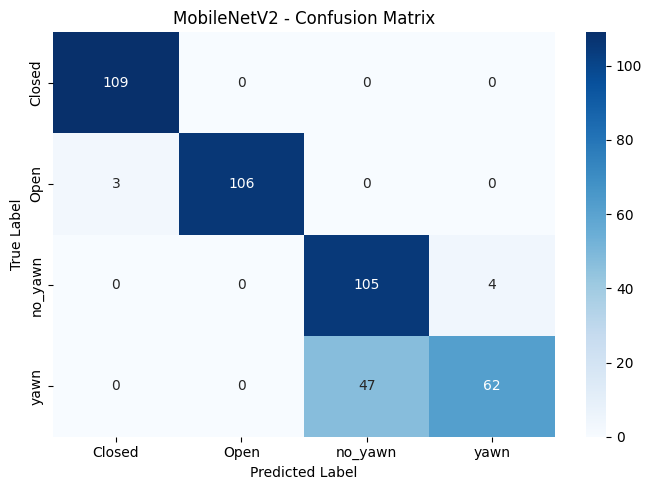

In [50]:
# Create confusion matrix for MobileNetV2

mobilenetv2_cm = confusion_matrix(
    mobilenetv2_y_true,
    mobilenetv2_y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    mobilenetv2_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

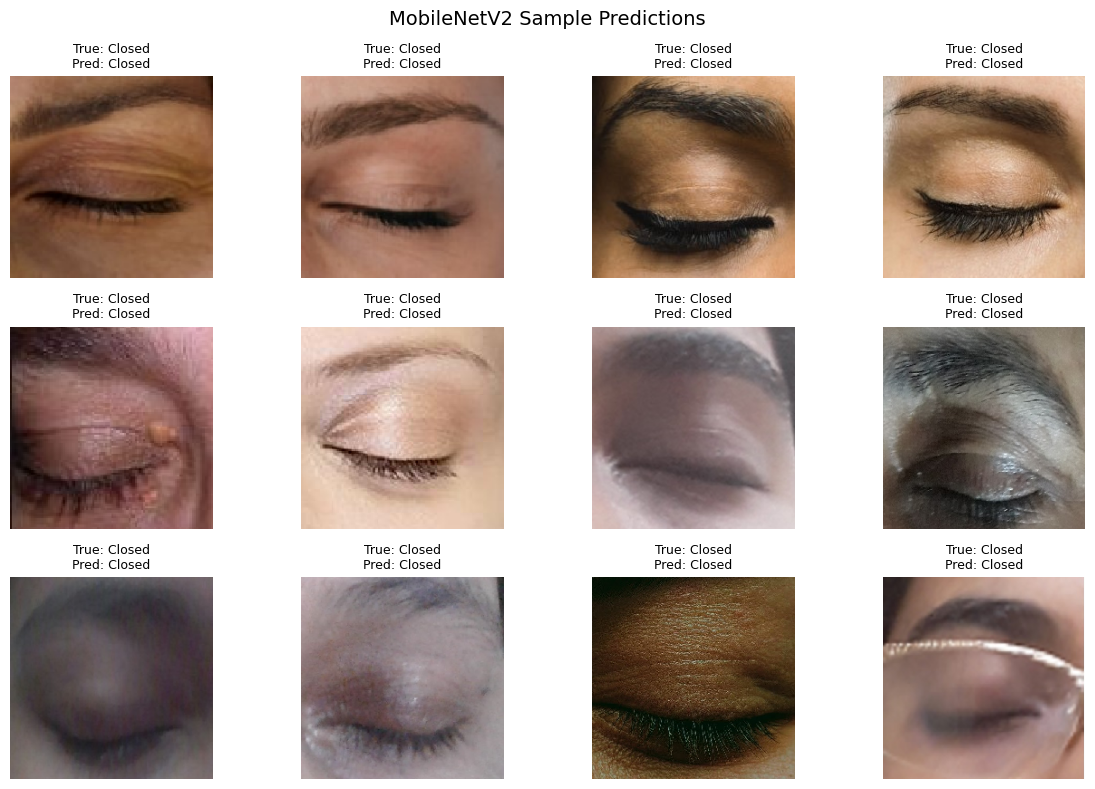

In [72]:
# Sample Predictions - MobileNetV2

sample_images, sample_labels = next(test_generator)

sample_predictions = mobilenetv2.predict(sample_images, verbose=0)
sample_pred_classes = np.argmax(sample_predictions, axis=1)
sample_true_classes = np.argmax(sample_labels, axis=1)

plt.figure(figsize=(12, 8))

for i in range(min(12, len(sample_images))):
    plt.subplot(3, 4, i + 1)

    plt.imshow(sample_images[i])
    plt.axis("off")

    true_label = class_names[sample_true_classes[i]]
    predicted_label = class_names[sample_pred_classes[i]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontsize=9
    )

plt.suptitle("MobileNetV2 Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

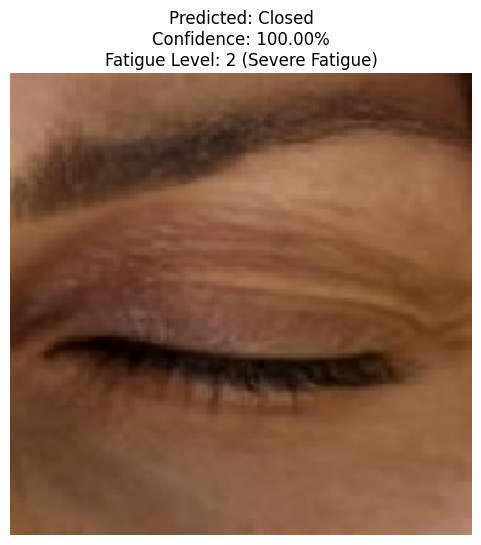

========== FINAL DROWSINESS RESULT ==========
Image: _103.jpg
Predicted State: Closed
Confidence: 100.00%
Fatigue Level: 2
Final Status: Severe Fatigue


In [74]:
# Single Image Prediction - Final Drowsiness Result

import os
from tensorflow.keras.utils import load_img, img_to_array

# Select one image from the test dataset
sample_path = test_generator.filepaths[0]

# Load and preprocess the image
image = load_img(sample_path, target_size=(224, 224))
image_array = img_to_array(image) / 255.0
image_batch = np.expand_dims(image_array, axis=0)

# Predict using MobileNetV2
prediction = mobilenetv2.predict(image_batch, verbose=0)

predicted_class_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_class_index]
confidence = prediction[0][predicted_class_index]

# Convert prediction to fatigue level
fatigue_level = fatigue_mapping[predicted_class]
fatigue_status = fatigue_labels[fatigue_level]

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%\n"
    f"Fatigue Level: {fatigue_level} ({fatigue_status})",
    fontsize=12
)
plt.show()

# Display final result
print("========== FINAL DROWSINESS RESULT ==========")
print(f"Image: {os.path.basename(sample_path)}")
print(f"Predicted State: {predicted_class}")
print(f"Confidence: {confidence * 100:.2f}%")
print(f"Fatigue Level: {fatigue_level}")
print(f"Final Status: {fatigue_status}")

In [73]:
#Model Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [0.8119, 0.8761],
    "Precision": [0.8132, 0.9008],
    "Recall": [0.8119, 0.8761],
    "Training Time (minutes)": [10.439614, 11.176018]
})

comparison_df

,Model,Test Accuracy,Precision,Recall,Training Time (minutes)
0,Custom CNN,0.8119,0.8132,0.8119,10.439614
1,MobileNetV2,0.8761,0.9008,0.8761,11.176018


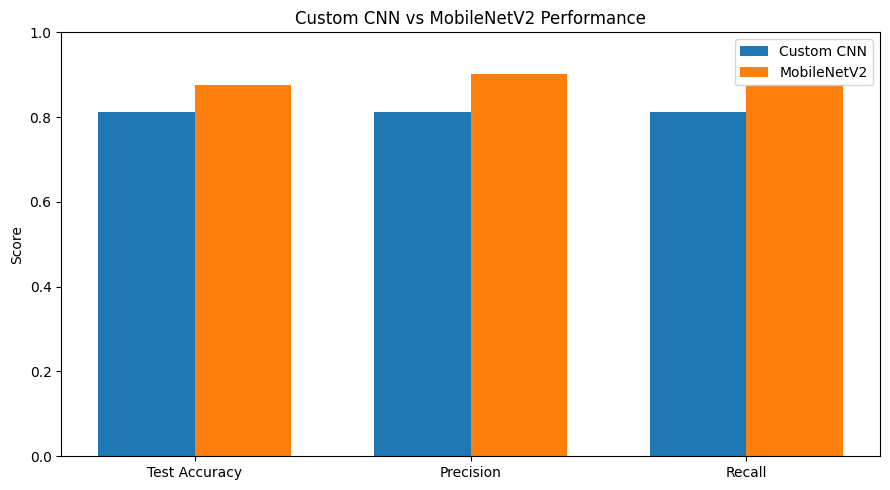

In [63]:
# Visualize model performance comparison

metrics = ["Test Accuracy", "Precision", "Recall"]

custom_cnn_scores = comparison_df.loc[
    comparison_df["Model"] == "Custom CNN",
    metrics
].values[0]

mobilenetv2_scores = comparison_df.loc[
    comparison_df["Model"] == "MobileNetV2",
    metrics
].values[0]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    custom_cnn_scores,
    width,
    label="Custom CNN"
)

plt.bar(
    x + width / 2,
    mobilenetv2_scores,
    width,
    label="MobileNetV2"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Custom CNN vs MobileNetV2 Performance")
plt.legend()
plt.tight_layout()
plt.show()

## Performance Analysis

The performance of the Custom CNN and MobileNetV2 models was compared using the unseen test dataset.

MobileNetV2 achieved better overall performance than the Custom CNN:

- **Custom CNN:** 81.19% test accuracy
- **MobileNetV2:** 87.61% test accuracy

MobileNetV2 also achieved higher precision and recall compared with the Custom CNN.

The models performed particularly well for the **Closed** and **Open** eye-state classes. However, some confusion was observed between the **Yawn** and **No Yawn** classes.

Possible factors affecting classification performance include:

- Lighting conditions
- Facial pose and orientation
- Image quality
- Background variation
- Different image cropping patterns

Overall, the results indicate that MobileNetV2 provided stronger generalization than the Custom CNN for this dataset.

In [64]:
# Define rule-based fatigue level mapping

fatigue_mapping = {
    "Open": 0,
    "no_yawn": 0,
    "yawn": 1,
    "Closed": 2
}

fatigue_labels = {
    0: "Alert",
    1: "Mild Fatigue",
    2: "Severe Fatigue"
}

print("Fatigue mapping created successfully!")
print(fatigue_mapping)

Fatigue mapping created successfully!
{'Open': 0, 'no_yawn': 0, 'yawn': 1, 'Closed': 2}


## Fatigue Decision Logic

The four-class model predictions are converted into three fatigue levels using rule-based decision logic.

| Predicted State | Fatigue Level | Interpretation |
|---|---:|---|
| Open | 0 | Alert |
| no_yawn | 0 | Alert |
| yawn | 1 | Mild Fatigue |
| Closed | 2 | Severe Fatigue |

The decision rules are:

- **Open + No Yawn → Alert**
- **Yawn → Mild Fatigue**
- **Closed → Severe Fatigue**

This rule-based mapping combines the detected eye and mouth states into a simple fatigue-level indicator.

A higher fatigue level represents a greater indication of driver drowsiness.

In [65]:
# Convert MobileNetV2 predictions into fatigue levels

predicted_classes = [
    class_names[index]
    for index in mobilenetv2_y_pred
]

fatigue_levels = [
    fatigue_mapping[class_name]
    for class_name in predicted_classes
]

fatigue_stage_names = [
    fatigue_labels[level]
    for level in fatigue_levels
]

print("Fatigue levels generated successfully!")
print("Total predictions:", len(fatigue_levels))

print("\nFirst 10 predictions:")
for i in range(10):
    print(
        f"{i + 1}. "
        f"Prediction: {predicted_classes[i]:8s} → "
        f"Level {fatigue_levels[i]} ({fatigue_stage_names[i]})"
    )

Fatigue levels generated successfully!
Total predictions: 436

First 10 predictions:
1. Prediction: Closed   → Level 2 (Severe Fatigue)
2. Prediction: Closed   → Level 2 (Severe Fatigue)
3. Prediction: Closed   → Level 2 (Severe Fatigue)
4. Prediction: Closed   → Level 2 (Severe Fatigue)
5. Prediction: Closed   → Level 2 (Severe Fatigue)
6. Prediction: Closed   → Level 2 (Severe Fatigue)
7. Prediction: Closed   → Level 2 (Severe Fatigue)
8. Prediction: Closed   → Level 2 (Severe Fatigue)
9. Prediction: Closed   → Level 2 (Severe Fatigue)
10. Prediction: Closed   → Level 2 (Severe Fatigue)


In [66]:
# Count the number of predictions at each fatigue level

fatigue_distribution = pd.Series(fatigue_stage_names).value_counts()

print("Fatigue Level Distribution:")
print(fatigue_distribution)

Fatigue Level Distribution:
Alert             258
Severe Fatigue    112
Mild Fatigue       66
Name: count, dtype: int64


## Fatigue Progression

Fatigue progression demonstrates how individual model predictions can be converted into a sequence of fatigue stages over time.

For this project, sequential class predictions are mapped to the three fatigue levels:

- **Level 0 — Alert**
- **Level 1 — Mild Fatigue**
- **Level 2 — Severe Fatigue**

The progression is represented as a time-based sequence, where each prediction corresponds to a time interval.

The sequence helps visualize transitions such as:

**Alert → Mild Fatigue → Severe Fatigue**

Since the available dataset contains individual images rather than continuous time-ordered driving-session data, the progression curve is **simulated** to demonstrate the decision-fusion concept.

In a real-world implementation, continuous video frames could be processed sequentially and grouped into fixed time intervals to monitor changes in driver fatigue.

In [67]:
#Simulated Progression Generation
simulated_predictions = [
    "Open",
    "no_yawn",
    "Open",
    "yawn",
    "yawn",
    "yawn",
    "no_yawn",
    "yawn",
    "yawn",
    "Closed",
    "Closed",
    "Closed"
]

simulated_fatigue_levels = [
    fatigue_mapping[pred]
    for pred in simulated_predictions
]

print("Simulated fatigue progression created successfully!")

for minute, level in enumerate(simulated_fatigue_levels):
    if level == 0:
        stage = "Alert"
    elif level == 1:
        stage = "Mild Fatigue"
    else:
        stage = "Severe Fatigue"

    print(f"Minute {minute}: Level {level} ({stage})")

Simulated fatigue progression created successfully!
Minute 0: Level 0 (Alert)
Minute 1: Level 0 (Alert)
Minute 2: Level 0 (Alert)
Minute 3: Level 1 (Mild Fatigue)
Minute 4: Level 1 (Mild Fatigue)
Minute 5: Level 1 (Mild Fatigue)
Minute 6: Level 0 (Alert)
Minute 7: Level 1 (Mild Fatigue)
Minute 8: Level 1 (Mild Fatigue)
Minute 9: Level 2 (Severe Fatigue)
Minute 10: Level 2 (Severe Fatigue)
Minute 11: Level 2 (Severe Fatigue)


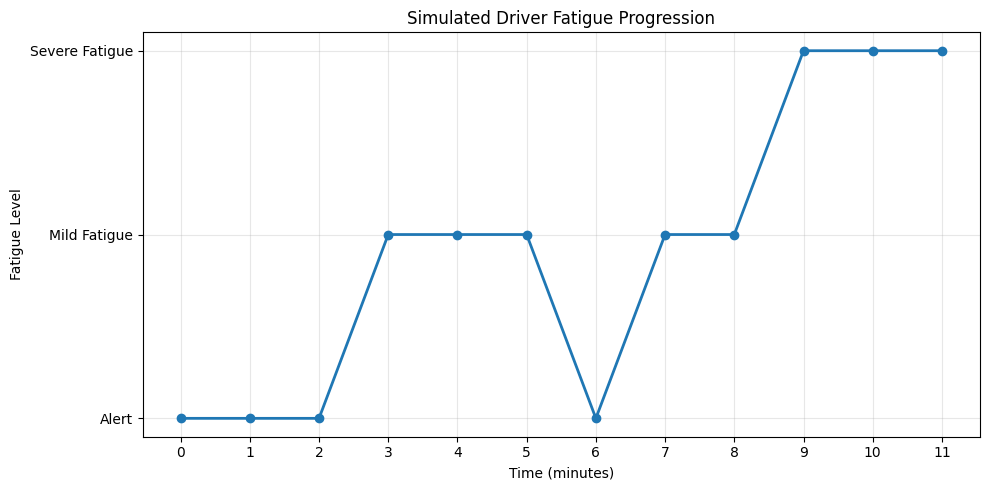

In [68]:
# Plot the simulated fatigue progression over time

plt.figure(figsize=(10, 5))

plt.plot(
    time_minutes,
    simulated_fatigue_levels,
    marker="o",
    linewidth=2
)

plt.yticks(
    [0, 1, 2],
    ["Alert", "Mild Fatigue", "Severe Fatigue"]
)

plt.xticks(time_minutes)

plt.xlabel("Time (minutes)")
plt.ylabel("Fatigue Level")
plt.title("Simulated Driver Fatigue Progression")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Limitations

- The dataset contains eye-state and mouth-state images, but it is not a continuous real-time driving video dataset.
- The current implementation performs image-level four-class classification.
- The fatigue progression curve is simulated because continuous time-ordered driving-session data is not available.
- Model performance may vary under extreme lighting conditions, unusual head poses, occlusion, or low-quality camera input.
- The current implementation uses a unified four-class classifier rather than separate binary eye and mouth models.
- Real-world deployment would require further testing with continuous video streams and diverse driving conditions.


## Business Use Cases

The proposed driver drowsiness detection system can support several real-world applications:

### 1. Accident Prevention and Road Safety
The system can identify visible signs of driver fatigue and provide early warnings to help reduce the risk of fatigue-related accidents.

### 2. Fleet Management and Driver Safety Analytics
Fleet operators can use fatigue monitoring to improve driver safety and identify patterns of drowsiness during driving operations.

### 3. Advanced Driver Assistance Systems (ADAS)
The drowsiness detection system can be integrated with ADAS to provide driver monitoring and support safer driving decisions.

### 4. Insurance Risk Assessment
Driver fatigue indicators could potentially support risk analysis and safety-focused insurance applications.

### 5. Smart Mobility and Autonomous Vehicle Support
Driver monitoring can be used in smart mobility systems and semi-autonomous vehicles to determine whether a driver remains sufficiently alert to take control when required.

## Reproducibility and Project Organization

The project was implemented in Google Colab as an end-to-end workflow covering dataset preparation, preprocessing, model training, evaluation, and visualization.

The workflow is organized into the following stages:

1. Dataset loading and verification
2. Exploratory Data Analysis
3. Data quality and duplicate analysis
4. Train-validation-test split
5. Image preprocessing and augmentation
6. Custom CNN model development
7. MobileNetV2 transfer learning
8. Model training and validation
9. Test-set evaluation
10. Confusion matrix and classification metrics
11. Model performance comparison
12. Fatigue-level decision logic
13. Fatigue progression visualization

The original dataset was preserved, and a fresh dataset split was created for the final implementation to maintain a clean and reproducible workflow.

# Final Results and Conclusion

## Final Model Comparison

Two deep learning approaches were implemented and evaluated:

- Custom CNN
- MobileNetV2 Transfer Learning

MobileNetV2 achieved better performance on the unseen test dataset.

| Model | Test Accuracy | Precision | Recall |
|---|---:|---:|---:|
| Custom CNN | 81.19% | 81.32% | 81.19% |
| MobileNetV2 | 87.61% | 90.08% | 87.61% |

## Fatigue Decision Logic

The four-class predictions are converted into three fatigue levels:

- Open + No Yawn → Alert
- Yawn → Mild Fatigue
- Closed → Severe Fatigue

## Conclusion

The project demonstrates a vision-based driver drowsiness detection system using deep learning.

MobileNetV2 provided stronger overall generalization than the Custom CNN on the unseen test dataset. The confusion matrices show that eye-state classification was highly accurate, while Yawn and No Yawn remained more challenging to distinguish.

A fatigue progression curve was also created to demonstrate how sequential predictions can be converted into fatigue stages.

The system demonstrates the potential of computer vision and deep learning for non-intrusive driver fatigue monitoring and road safety applications.